<a href="https://www.kaggle.com/code/lalit7881/student-performance-prediction-eda-100?scriptVersionId=320376779" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aiexplorer77/academic-performance-prediction/student_performance_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aiexplorer77/academic-performance-prediction/student_performance_dataset.csv")

In [3]:
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [4]:
df.tail()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
2995,2995,22,Female,Rural,2.4,0,40,83,1.0,0,...,10,2,Practical,Arts,9,10,7,9,45,Low
2996,2996,19,Female,Urban,5.2,7,94,100,1.4,0,...,1,10,Visual,Medical,5,3,7,9,100,High
2997,2997,23,Female,Rural,5.9,2,41,86,5.4,1,...,7,10,Practical,Engineering,6,8,10,10,50,Medium
2998,2998,17,Male,Urban,3.9,1,92,96,2.8,1,...,3,10,Practical,Medical,4,7,1,4,76,High
2999,2999,16,Female,Semi-Urban,5.8,0,84,100,3.8,1,...,1,3,Audio,Arts,8,9,2,10,100,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [6]:
df.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [7]:
df.isnull()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_sc

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

student_id                       int64
age                              int64
gender                          object
city_type                       object
study_hours_per_day            float64
deep_work_sessions               int64
assignment_completion_rate       int64
attendance_percentage            int64
social_media_hours             float64
doomscrolling_before_sleep       int64
notification_distractions        int64
ai_tool_usage_hours            float64
gaming_hours                   float64
stress_level                     int64
motivation_level                 int64
focus_score                    float64
procrastination_index            int64
mental_state                    object
sleep_hours                    float64
caffeine_intake                  int64
physical_activity_hours        float64
internet_quality                 int64
family_support                   int64
financial_stress                 int64
learning_style                  object
career_goal              

In [11]:
df.shape

(3000, 32)

In [12]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

In [13]:
df.nunique()

student_id                     3000
age                               9
gender                            2
city_type                         3
study_hours_per_day              82
deep_work_sessions                8
assignment_completion_rate       61
attendance_percentage            51
social_media_hours               76
doomscrolling_before_sleep        2
notification_distractions       115
ai_tool_usage_hours              50
gaming_hours                     68
stress_level                     10
motivation_level                 10
focus_score                      10
procrastination_index            10
mental_state                      4
sleep_hours                      70
caffeine_intake                   8
physical_activity_hours          39
internet_quality                 10
family_support                   10
financial_stress                 10
learning_style                    4
career_goal                       5
productivity_after_midnight      10
revision_efficiency         

## EDA

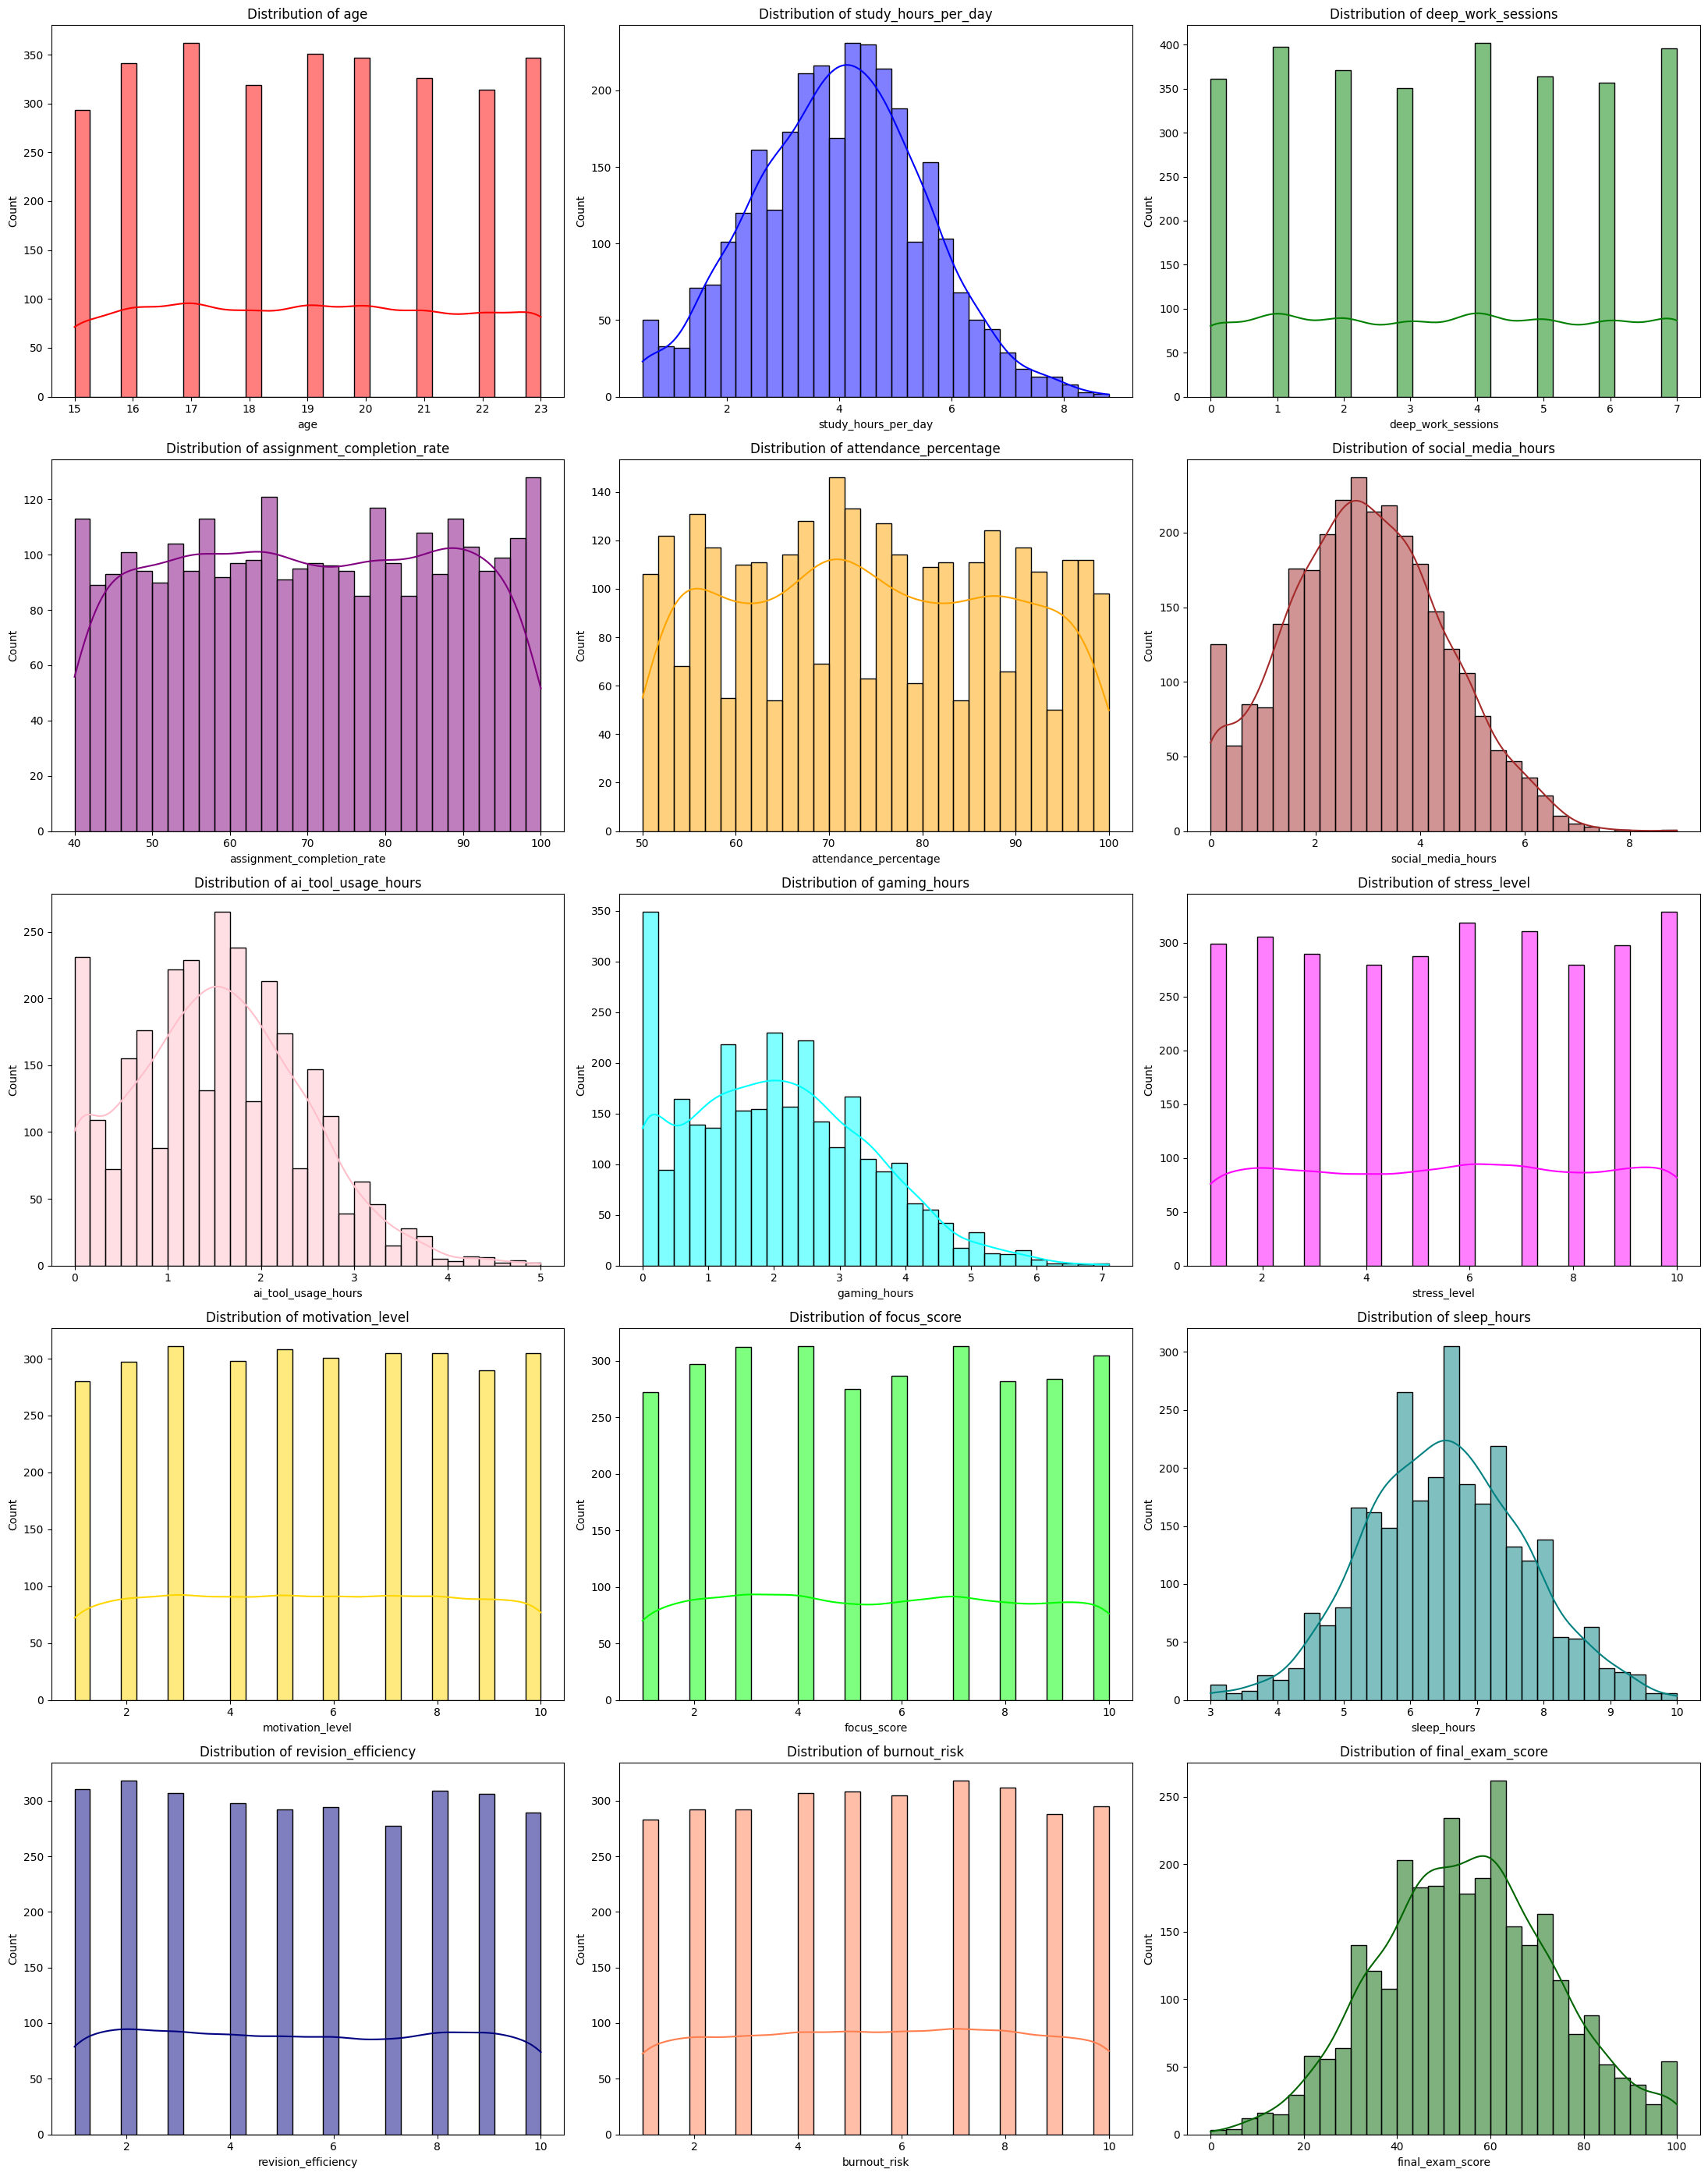

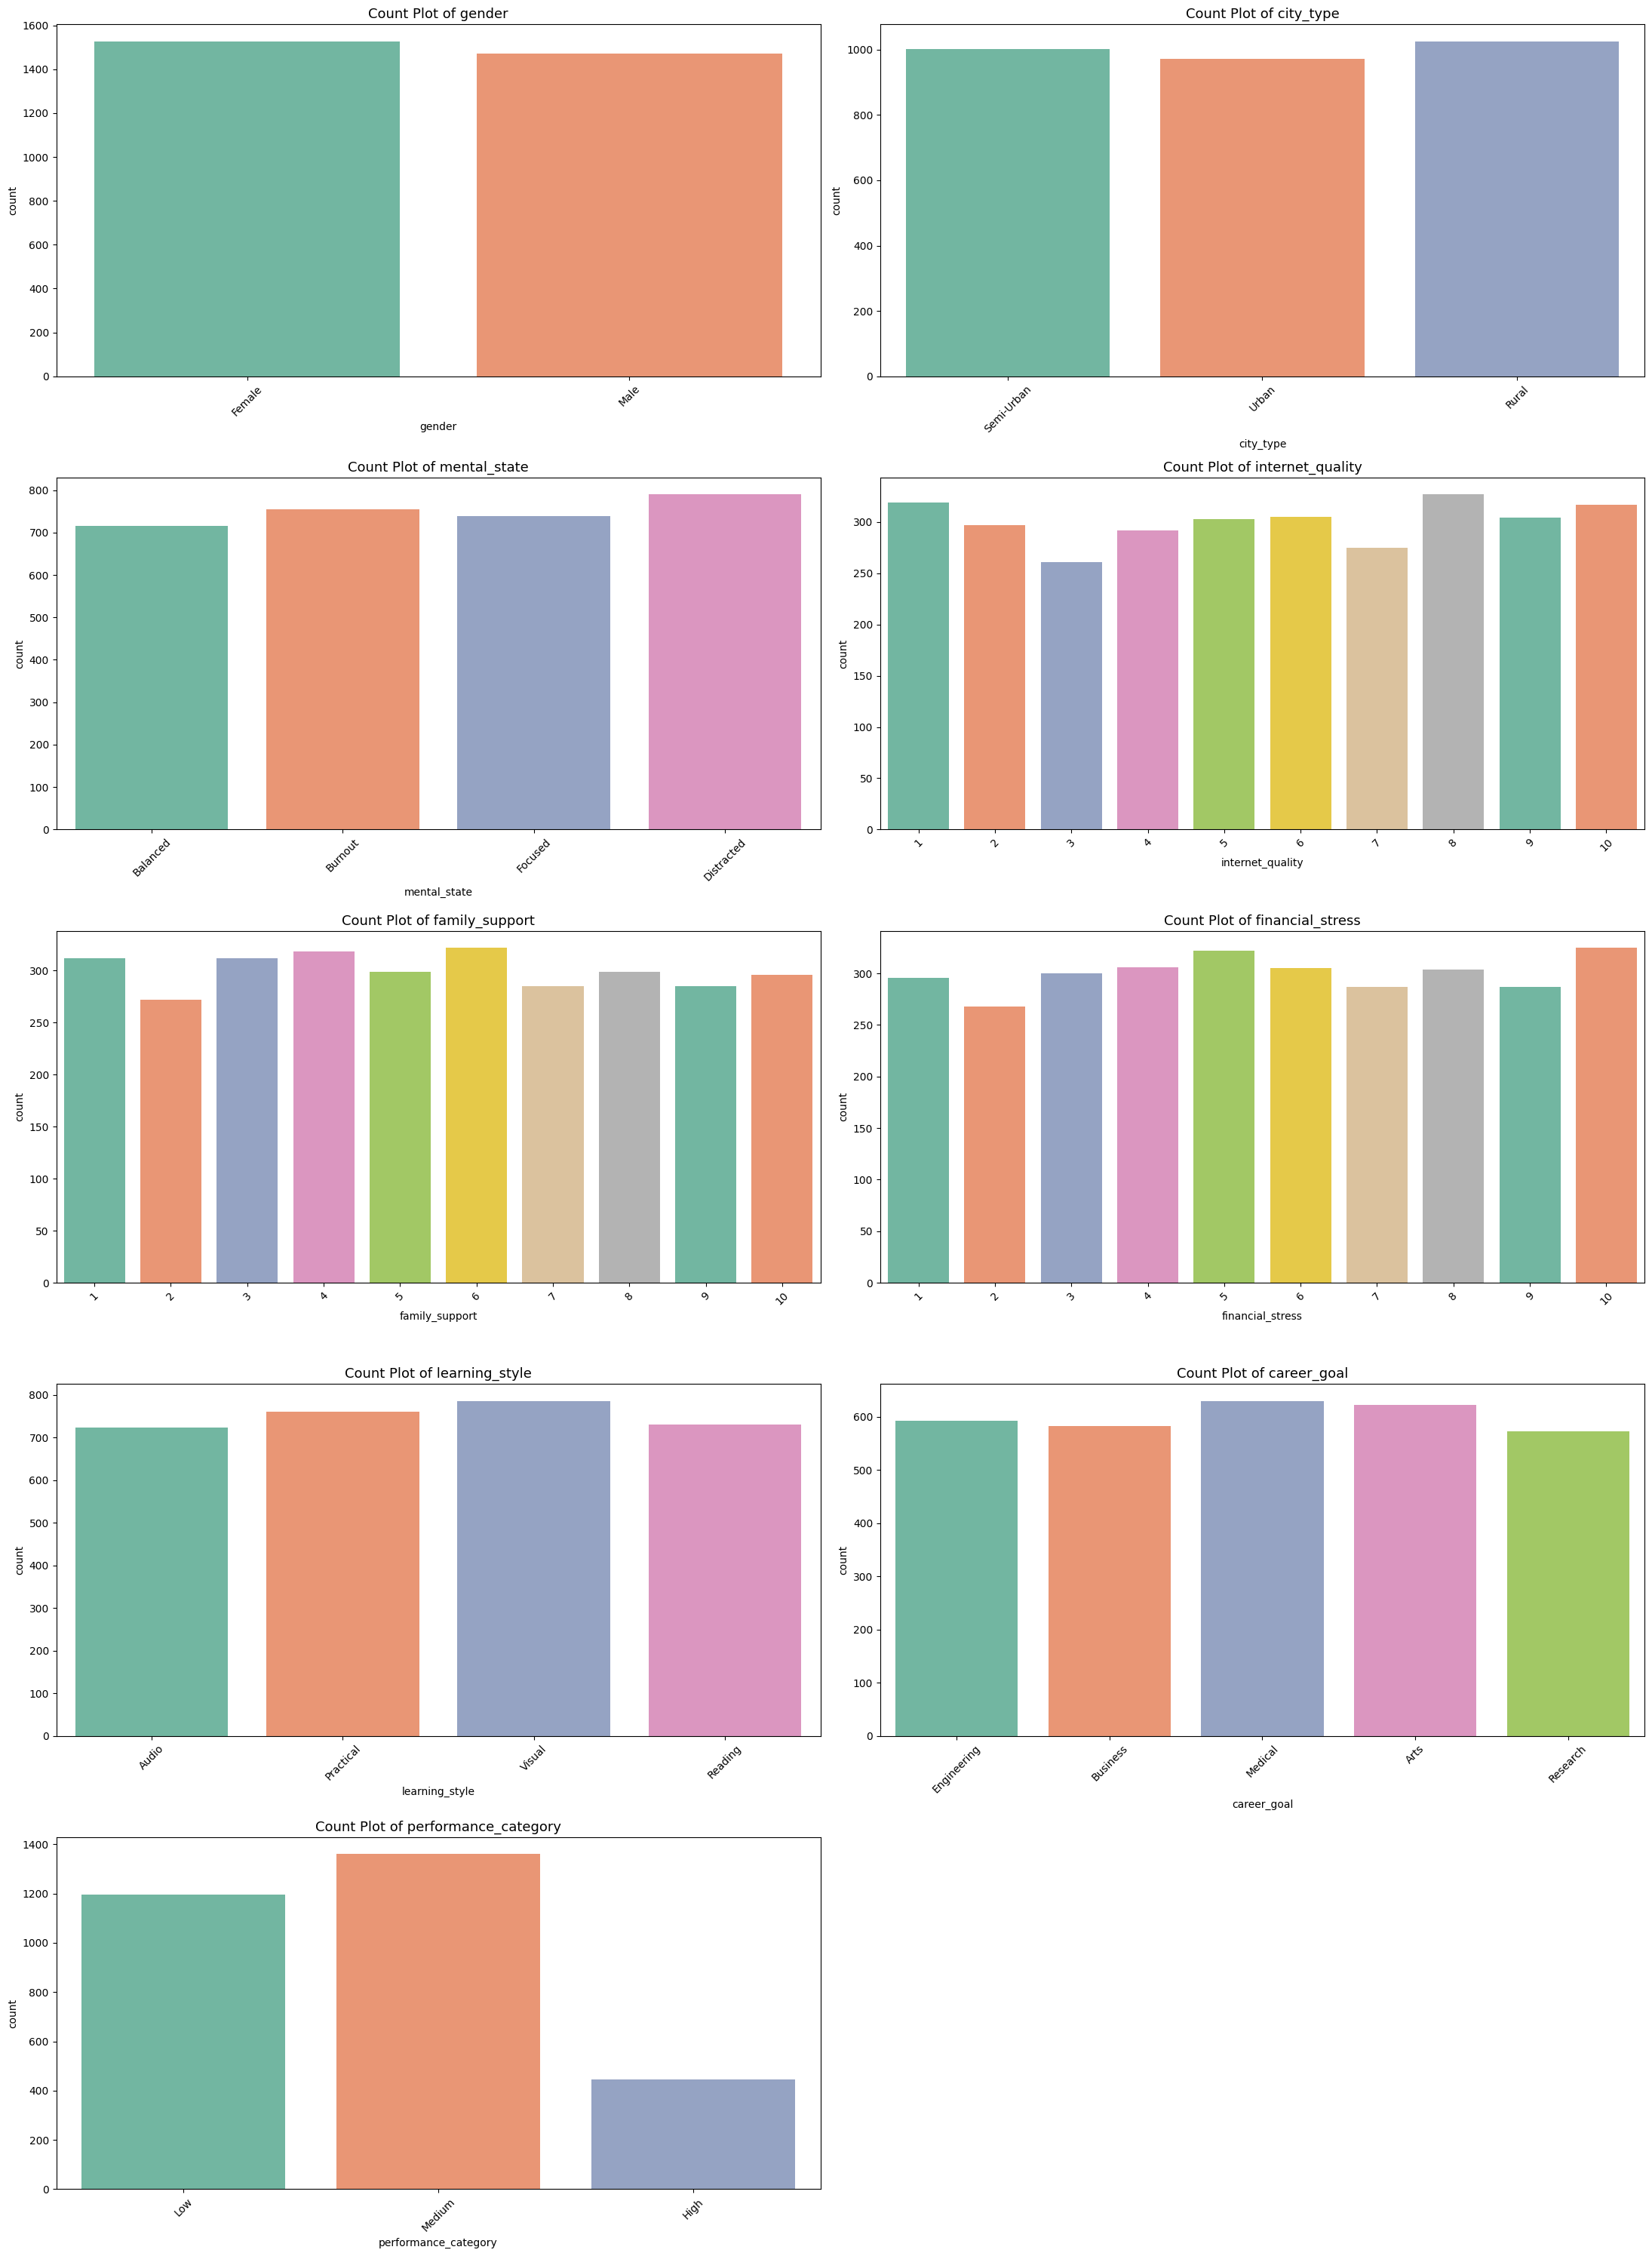

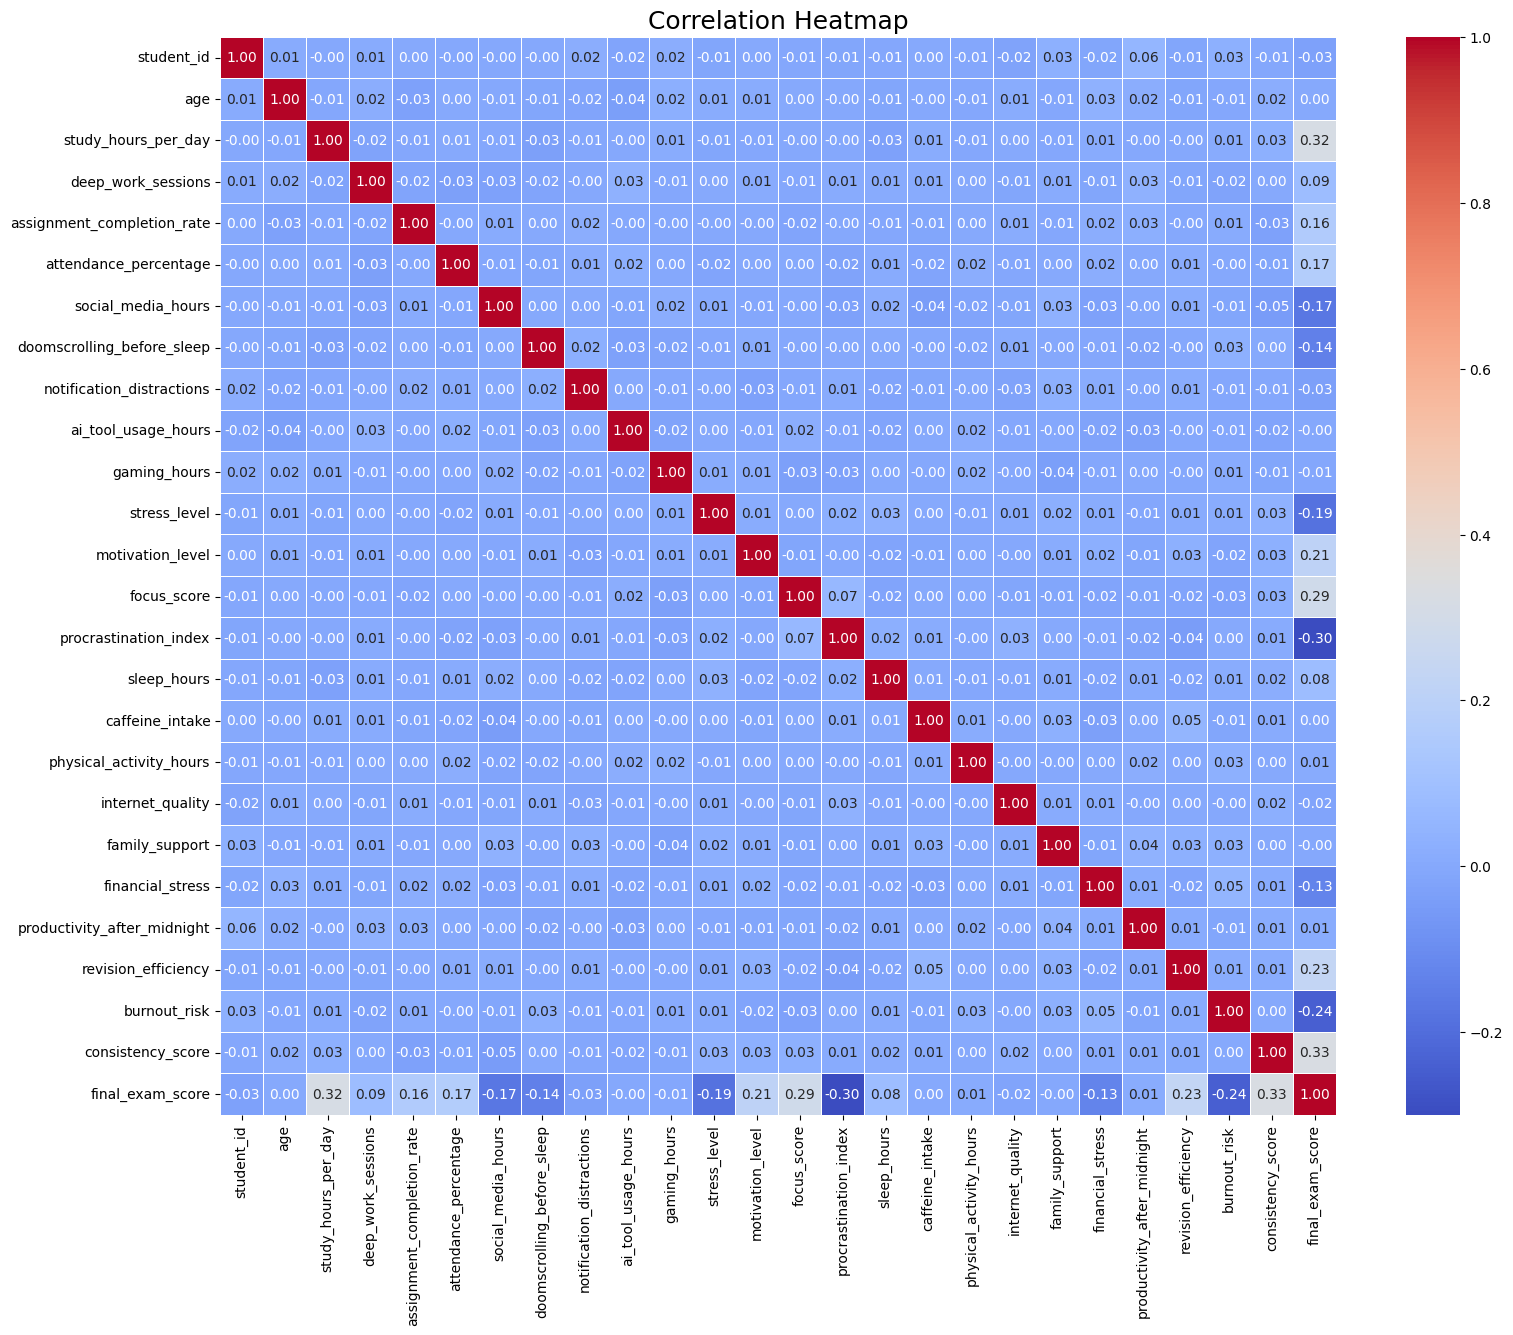

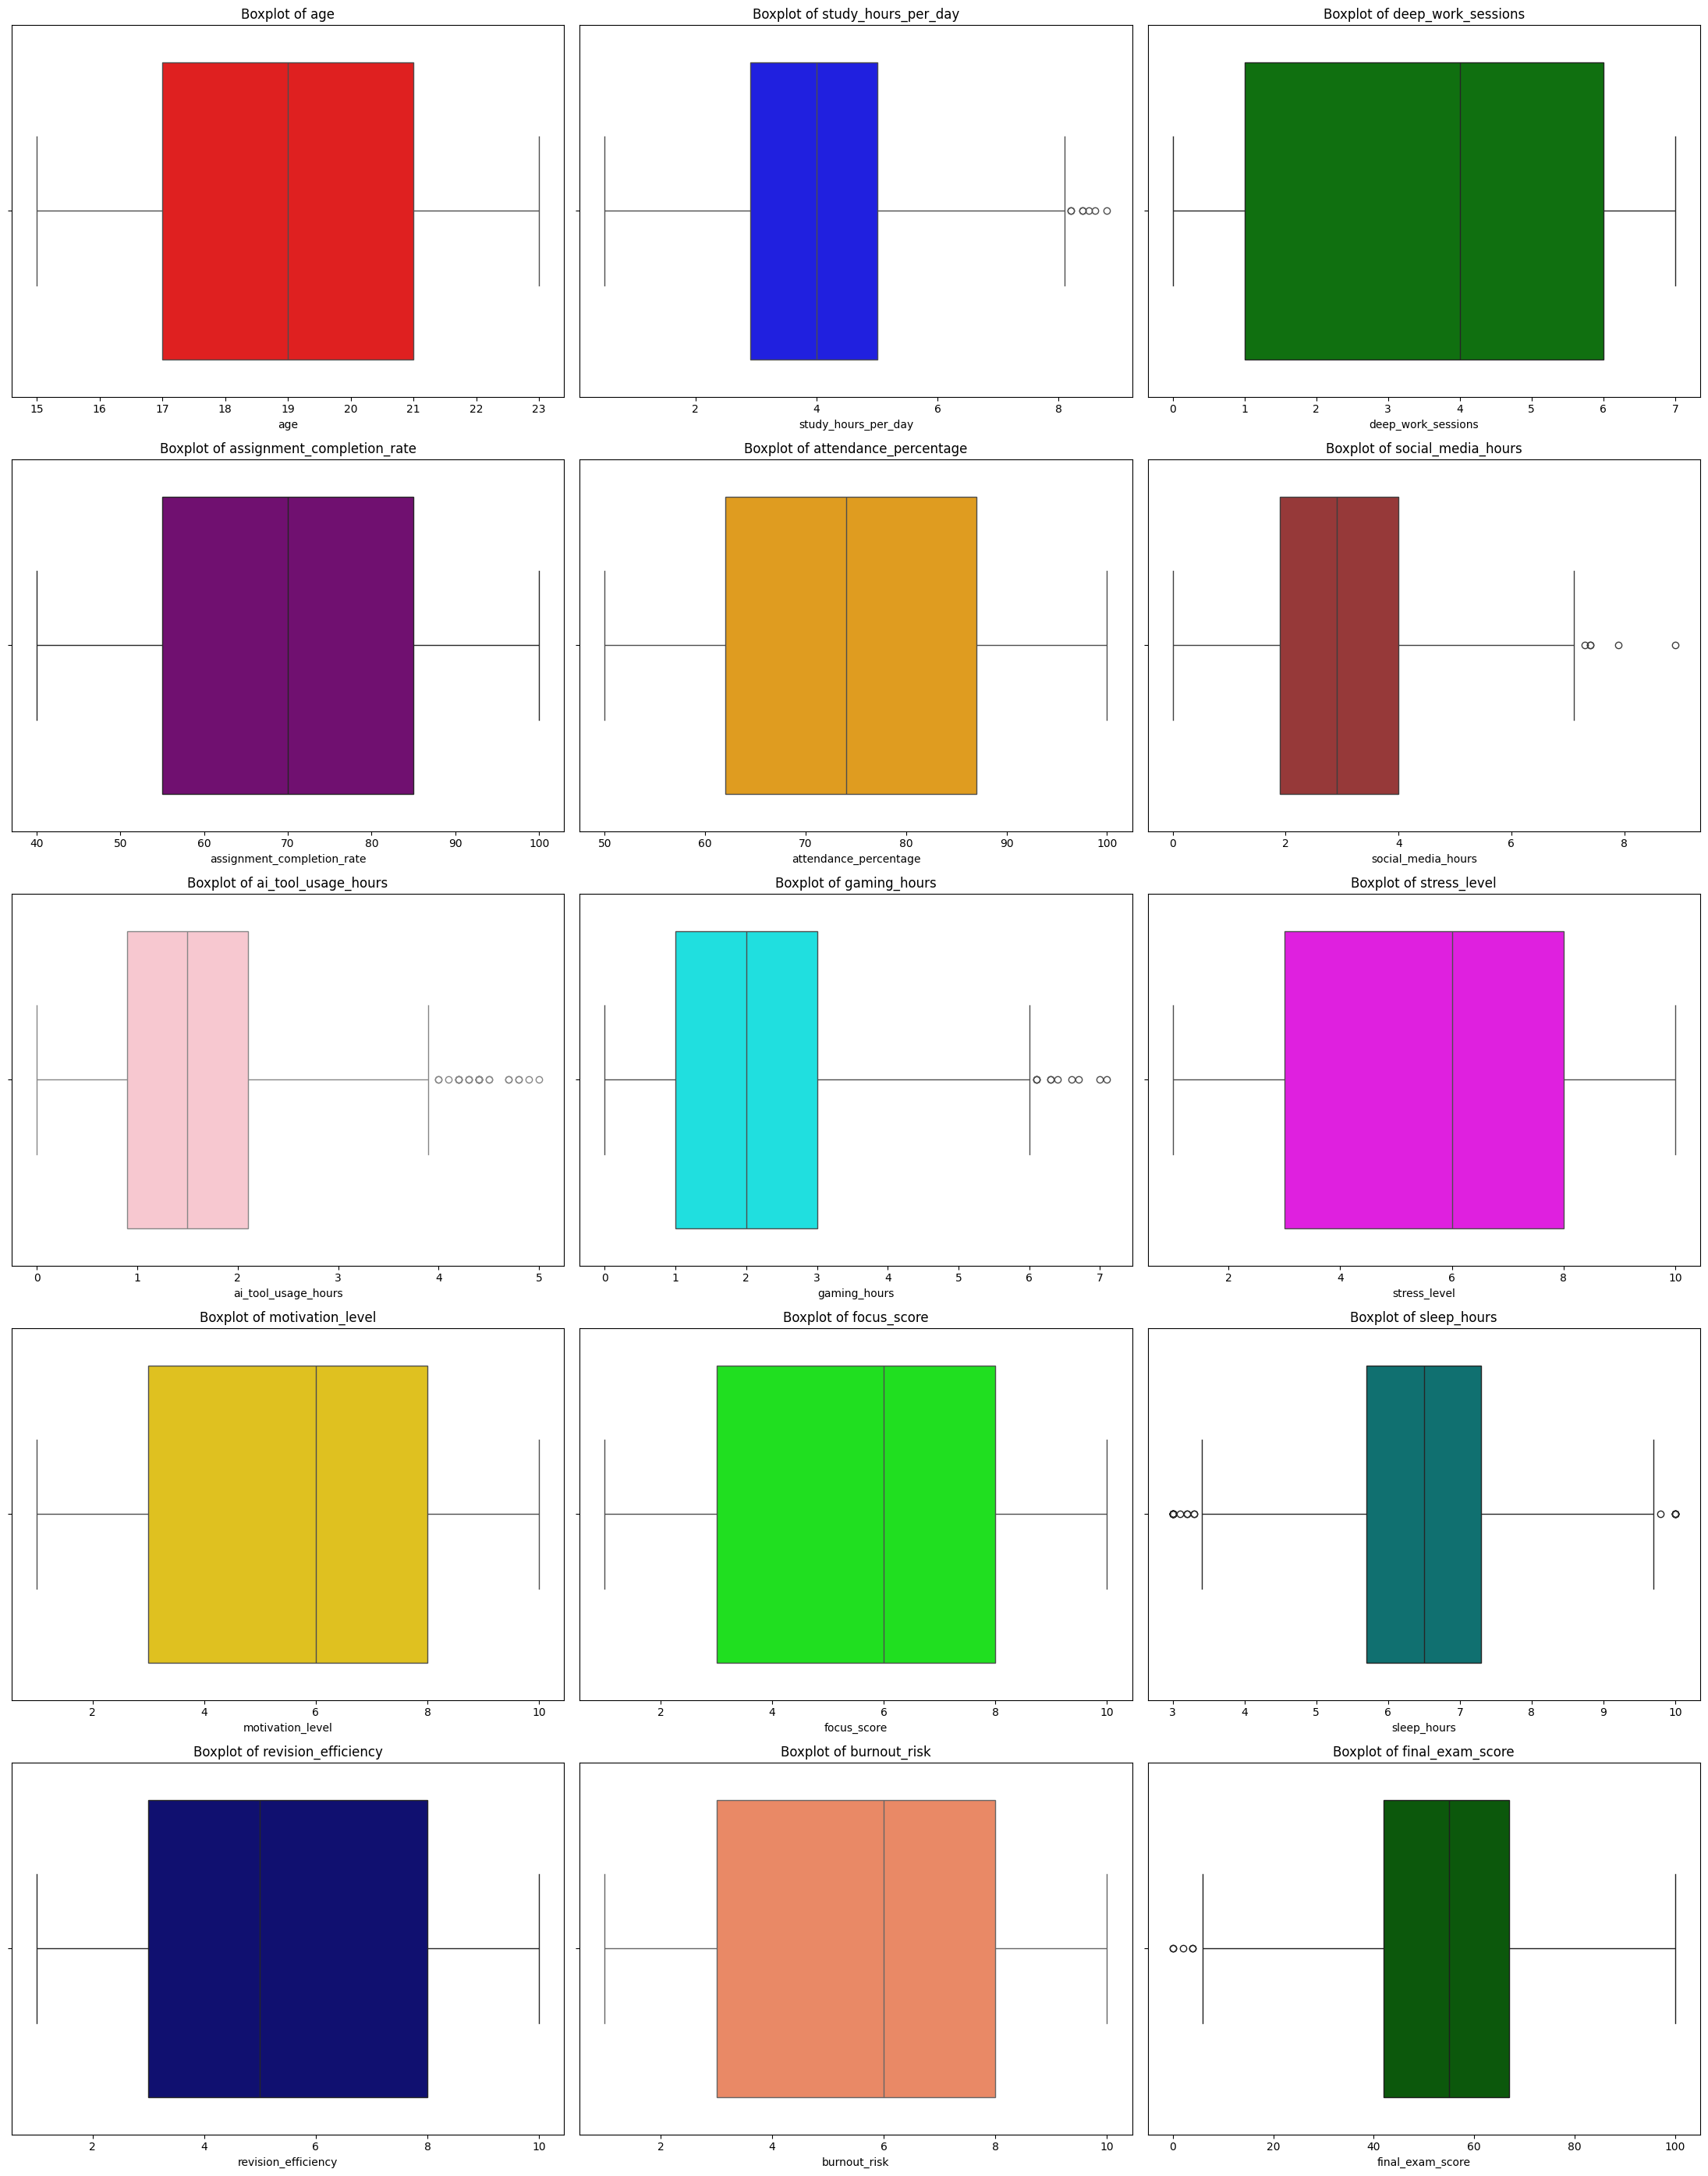

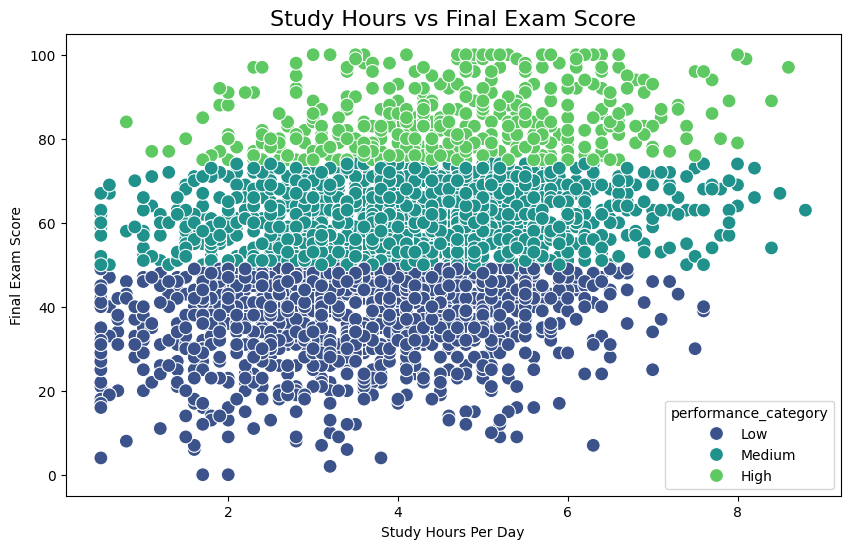

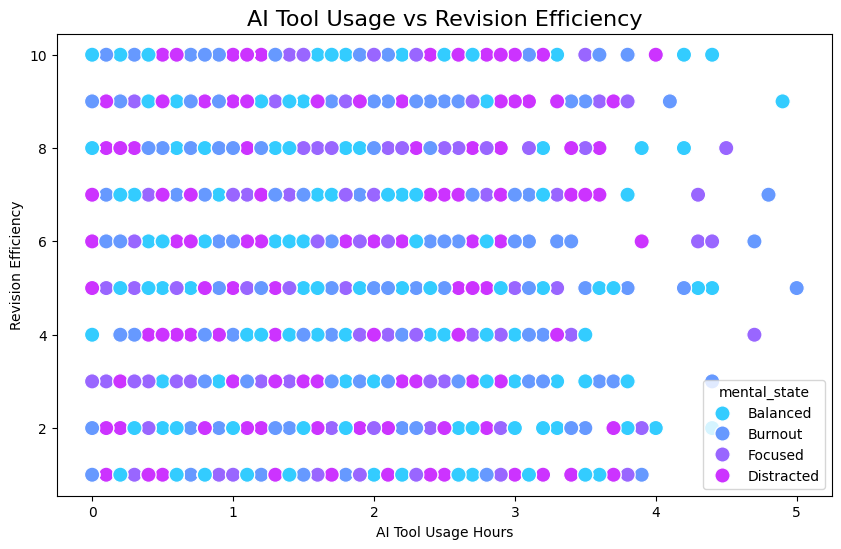

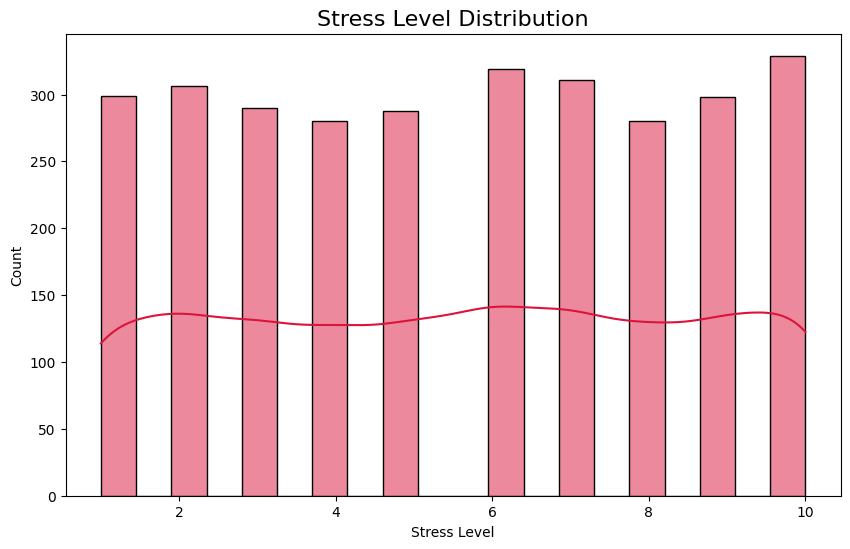

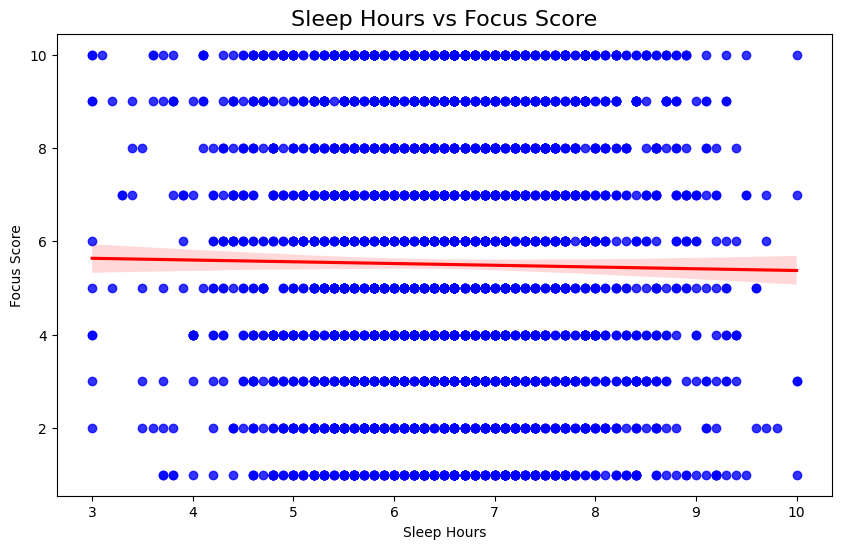

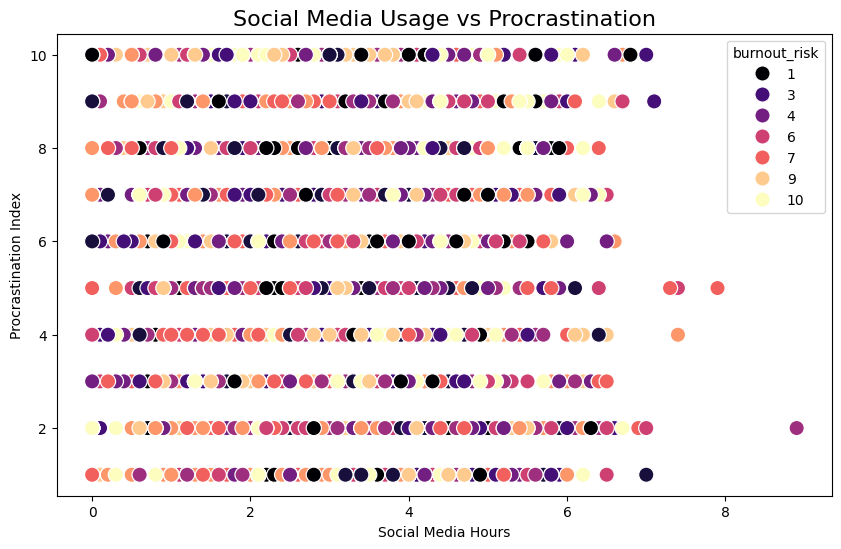

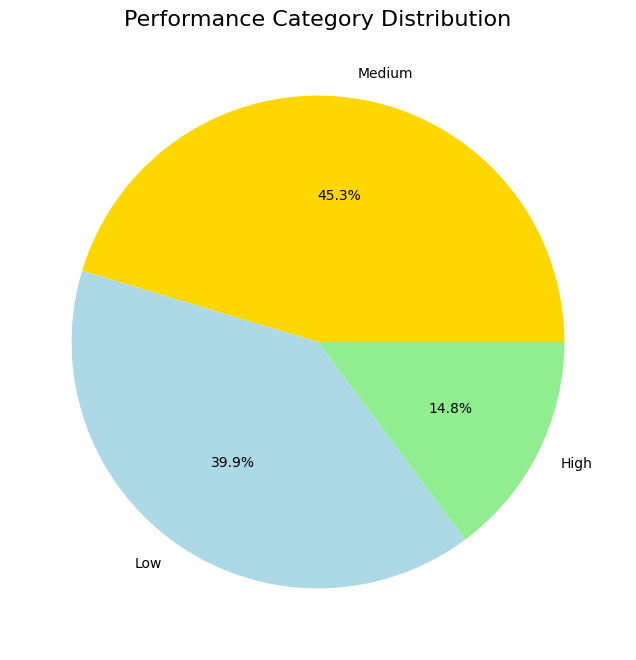

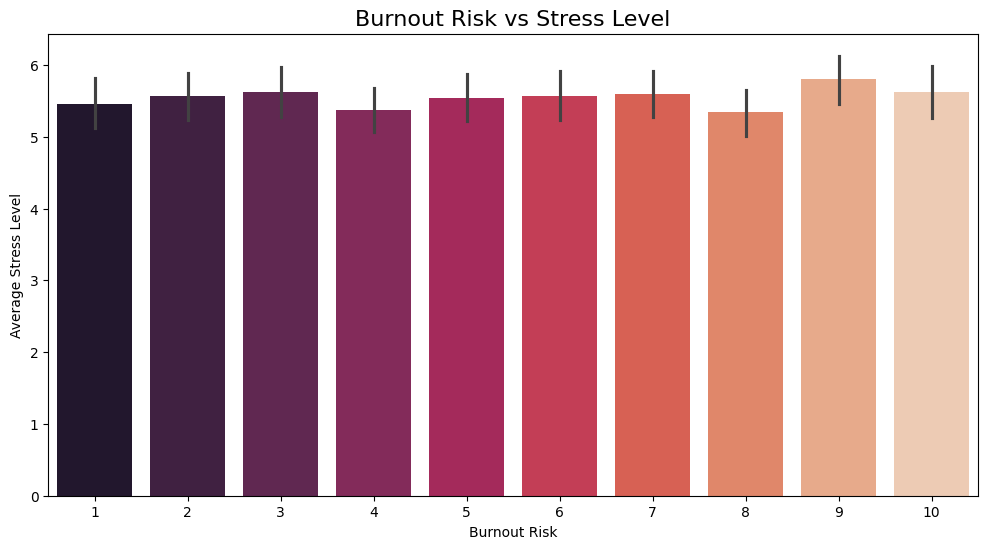

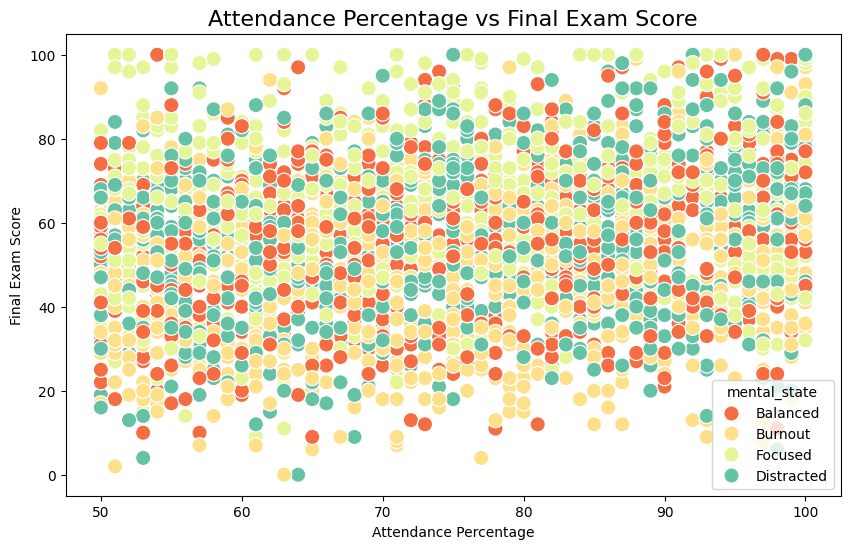

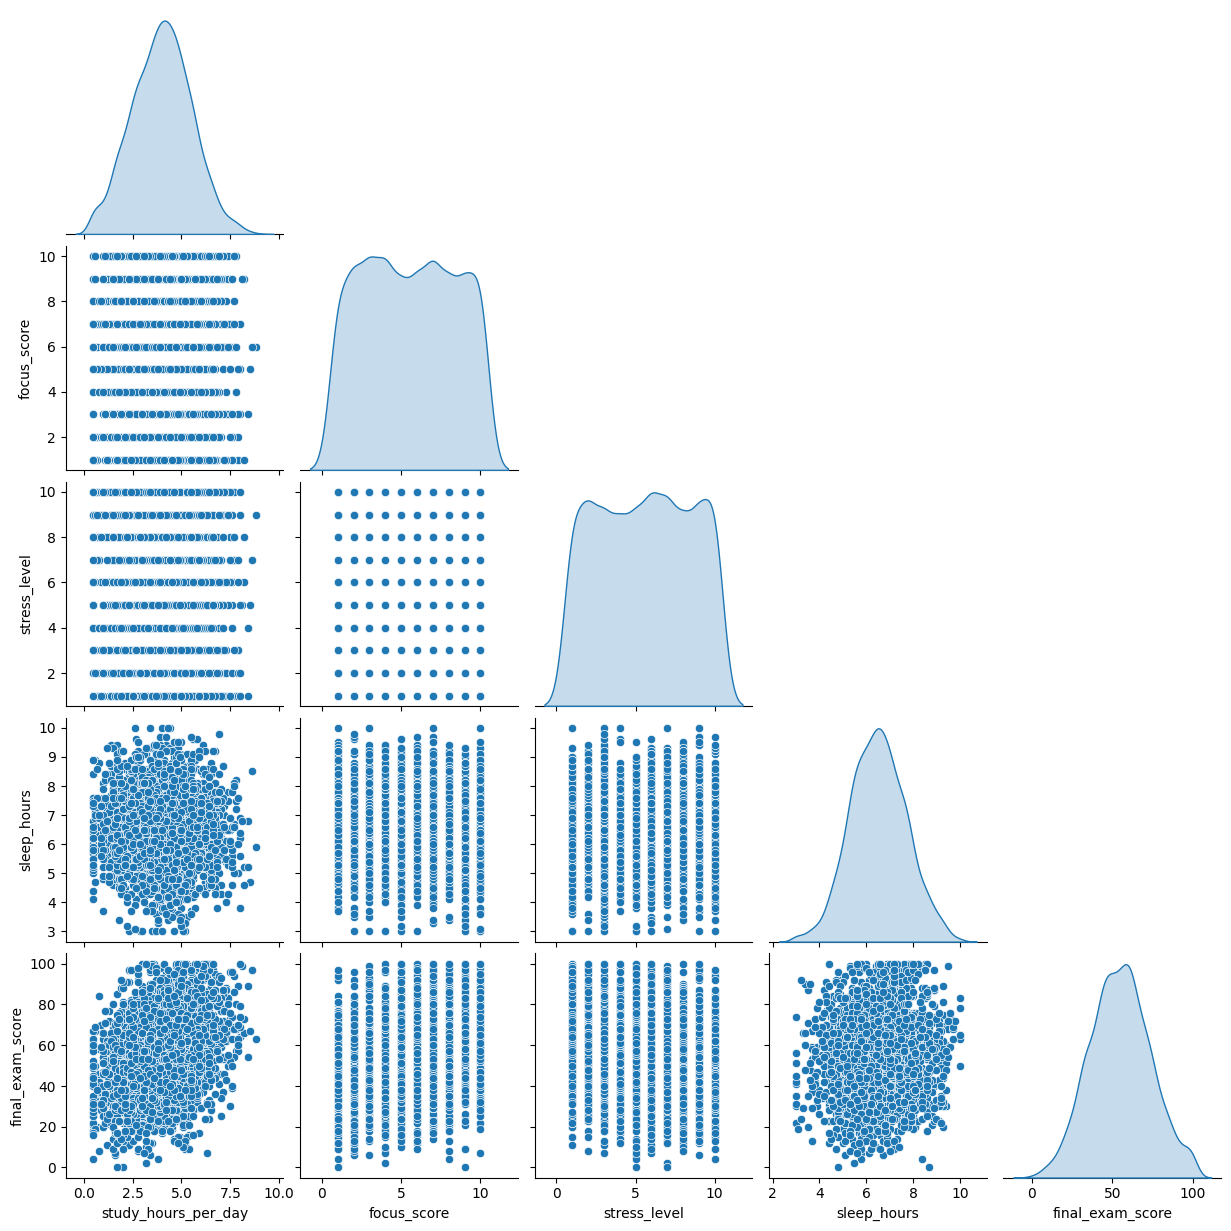

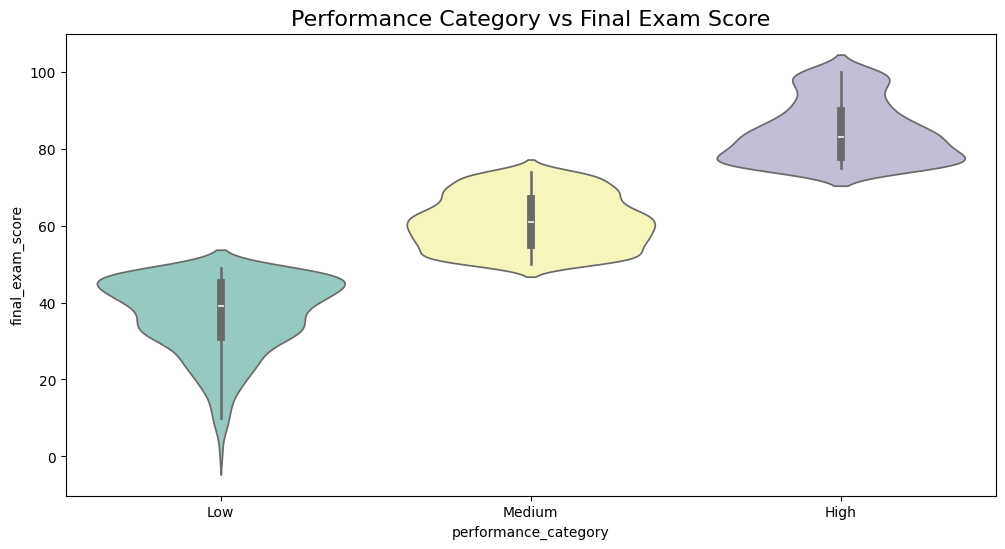

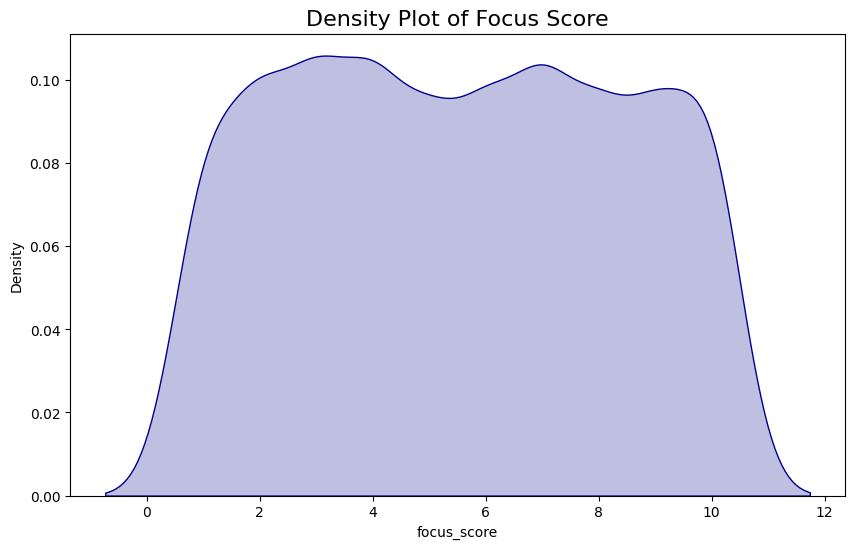

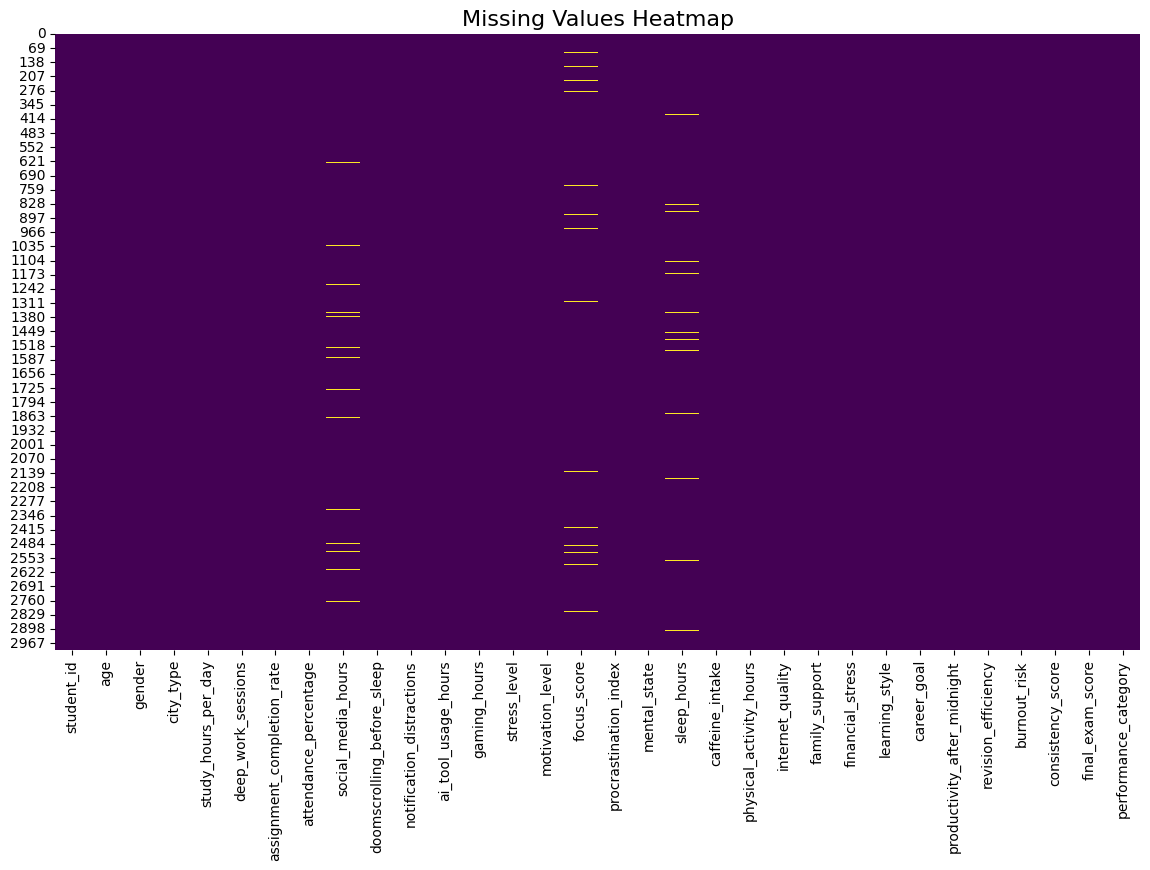


Correlation with Final Exam Score:

final_exam_score               1.000000
consistency_score              0.329144
study_hours_per_day            0.317229
focus_score                    0.286838
revision_efficiency            0.230729
motivation_level               0.209093
attendance_percentage          0.172020
assignment_completion_rate     0.159037
deep_work_sessions             0.086185
sleep_hours                    0.082183
productivity_after_midnight    0.014107
physical_activity_hours        0.008024
caffeine_intake                0.000743
age                            0.000172
ai_tool_usage_hours           -0.003776
family_support                -0.004131
gaming_hours                  -0.010042
internet_quality              -0.018411
student_id                    -0.025445
notification_distractions     -0.031477
financial_stress              -0.127100
doomscrolling_before_sleep    -0.138240
social_media_hours            -0.172449
stress_level                  -0.186721
bur

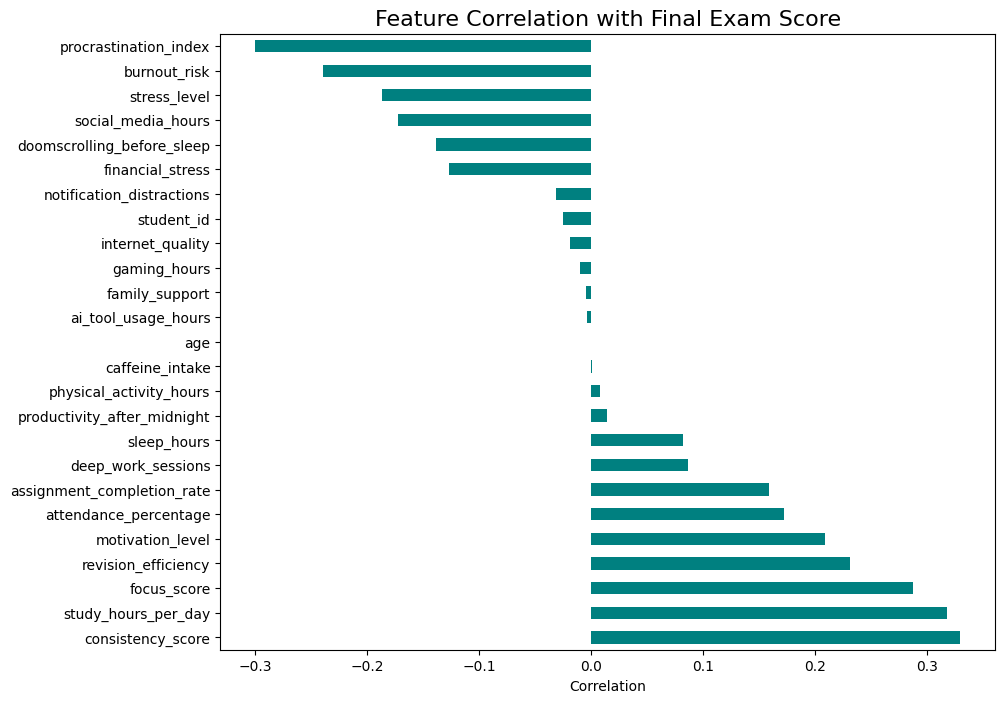


Visualization Completed Successfully!


In [14]:
# ============================================================
# 1. DISTRIBUTION OF NUMERICAL FEATURES
# ============================================================

numerical_cols = [
    'age',
    'study_hours_per_day',
    'deep_work_sessions',
    'assignment_completion_rate',
    'attendance_percentage',
    'social_media_hours',
    'ai_tool_usage_hours',
    'gaming_hours',
    'stress_level',
    'motivation_level',
    'focus_score',
    'sleep_hours',
    'revision_efficiency',
    'burnout_risk',
    'final_exam_score'
]

plt.figure(figsize=(22, 28))

colors = [
    'red', 'blue', 'green', 'purple', 'orange',
    'brown', 'pink', 'cyan', 'magenta', 'gold',
    'lime', 'teal', 'navy', 'coral', 'darkgreen'
]

for i, col in enumerate(numerical_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=colors[i],
        bins=30
    )
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# ============================================================
# 2. COUNT PLOTS FOR CATEGORICAL FEATURES
# ============================================================

categorical_cols = [
    'gender',
    'city_type',
    'mental_state',
    'internet_quality',
    'family_support',
    'financial_stress',
    'learning_style',
    'career_goal',
    'performance_category'
]

plt.figure(figsize=(22, 30))

cat_colors = [
    'red', 'blue', 'green', 'purple', 'orange',
    'brown', 'pink', 'cyan', 'magenta'
]

for i, col in enumerate(categorical_cols):
    plt.subplot(5, 2, i + 1)

    sns.countplot(
        data=df,
        x=col,
        palette='Set2'
    )

    plt.title(f'Count Plot of {col}', fontsize=13)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 3. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(18, 14))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# ============================================================
# 4. BOXPLOTS FOR OUTLIER DETECTION
# ============================================================

plt.figure(figsize=(22, 28))

for i, col in enumerate(numerical_cols):
    plt.subplot(5, 3, i + 1)

    sns.boxplot(
        x=df[col],
        color=colors[i]
    )

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# ============================================================
# 5. STUDY HOURS VS FINAL EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='study_hours_per_day',
    y='final_exam_score',
    hue='performance_category',
    palette='viridis',
    s=100
)

plt.title('Study Hours vs Final Exam Score', fontsize=16)
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Exam Score')
plt.show()

# ============================================================
# 6. AI TOOL USAGE VS PRODUCTIVITY
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='ai_tool_usage_hours',
    y='revision_efficiency',
    hue='mental_state',
    palette='cool',
    s=120
)

plt.title('AI Tool Usage vs Revision Efficiency', fontsize=16)
plt.xlabel('AI Tool Usage Hours')
plt.ylabel('Revision Efficiency')
plt.show()

# ============================================================
# 7. STRESS LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df['stress_level'],
    kde=True,
    color='crimson',
    bins=20
)

plt.title('Stress Level Distribution', fontsize=16)
plt.xlabel('Stress Level')
plt.show()

# ============================================================
# 8. SLEEP HOURS VS FOCUS SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='sleep_hours',
    y='focus_score',
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)

plt.title('Sleep Hours vs Focus Score', fontsize=16)
plt.xlabel('Sleep Hours')
plt.ylabel('Focus Score')
plt.show()

# ============================================================
# 9. SOCIAL MEDIA HOURS VS PROCRASTINATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='social_media_hours',
    y='procrastination_index',
    hue='burnout_risk',
    palette='magma',
    s=120
)

plt.title('Social Media Usage vs Procrastination', fontsize=16)
plt.xlabel('Social Media Hours')
plt.ylabel('Procrastination Index')
plt.show()

# ============================================================
# 10. PERFORMANCE CATEGORY PIE CHART
# ============================================================

performance_counts = df['performance_category'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    performance_counts,
    labels=performance_counts.index,
    autopct='%1.1f%%',
    colors=['gold', 'lightblue', 'lightgreen', 'salmon']
)

plt.title('Performance Category Distribution', fontsize=16)
plt.show()

# ============================================================
# 11. BURNOUT RISK VS STRESS LEVEL
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='burnout_risk',
    y='stress_level',
    palette='rocket'
)

plt.title('Burnout Risk vs Stress Level', fontsize=16)
plt.xlabel('Burnout Risk')
plt.ylabel('Average Stress Level')
plt.show()

# ============================================================
# 12. ATTENDANCE VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='attendance_percentage',
    y='final_exam_score',
    hue='mental_state',
    palette='Spectral',
    s=120
)

plt.title('Attendance Percentage vs Final Exam Score', fontsize=16)
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Exam Score')
plt.show()

# ============================================================
# 13. PAIRPLOT
# ============================================================

pairplot_cols = [
    'study_hours_per_day',
    'focus_score',
    'stress_level',
    'sleep_hours',
    'final_exam_score'
]

sns.pairplot(
    df[pairplot_cols],
    corner=True,
    diag_kind='kde'
)

plt.show()

# ============================================================
# 14. VIOLIN PLOT
# ============================================================

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='performance_category',
    y='final_exam_score',
    palette='Set3'
)

plt.title('Performance Category vs Final Exam Score', fontsize=16)
plt.show()

# ============================================================
# 15. KDE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='focus_score',
    fill=True,
    color='darkblue'
)

plt.title('Density Plot of Focus Score', fontsize=16)
plt.show()

# ============================================================
# 16. HEATMAP OF MISSING VALUES
# ============================================================

plt.figure(figsize=(14, 8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap', fontsize=16)
plt.show()

# ============================================================
# 17. TOP FEATURES CORRELATED WITH EXAM SCORE
# ============================================================

corr_target = correlation['final_exam_score'].sort_values(ascending=False)

print("\nCorrelation with Final Exam Score:\n")
print(corr_target)

plt.figure(figsize=(10, 8))

corr_target.drop('final_exam_score').plot(
    kind='barh',
    color='teal'
)

plt.title('Feature Correlation with Final Exam Score', fontsize=16)
plt.xlabel('Correlation')
plt.show()

# ============================================================
# END OF VISUALIZATION
# ============================================================

print("\nVisualization Completed Successfully!")

## Feature Engineering



TARGET COLUMN
performance_category
Medium    1360
Low       1196
High       444
Name: count, dtype: int64


TRAIN TEST SHAPE
X_train : (2400, 31)
X_test  : (600, 31)
y_train : (2400,)
y_test  : (600,)


CATEGORICAL COLUMNS
['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal']


NUMERICAL COLUMNS
['student_id', 'age', 'study_hours_per_day', 'deep_work_sessions', 'assignment_completion_rate', 'attendance_percentage', 'social_media_hours', 'doomscrolling_before_sleep', 'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours', 'stress_level', 'motivation_level', 'focus_score', 'procrastination_index', 'sleep_hours', 'caffeine_intake', 'physical_activity_hours', 'internet_quality', 'family_support', 'financial_stress', 'productivity_after_midnight', 'revision_efficiency', 'burnout_risk', 'consistency_score', 'final_exam_score']


MODEL : Logistic Regression

Accuracy Score : 0.9333

Classification Report

              precision    recall  f1-score   support



<Figure size 1400x1000 with 0 Axes>

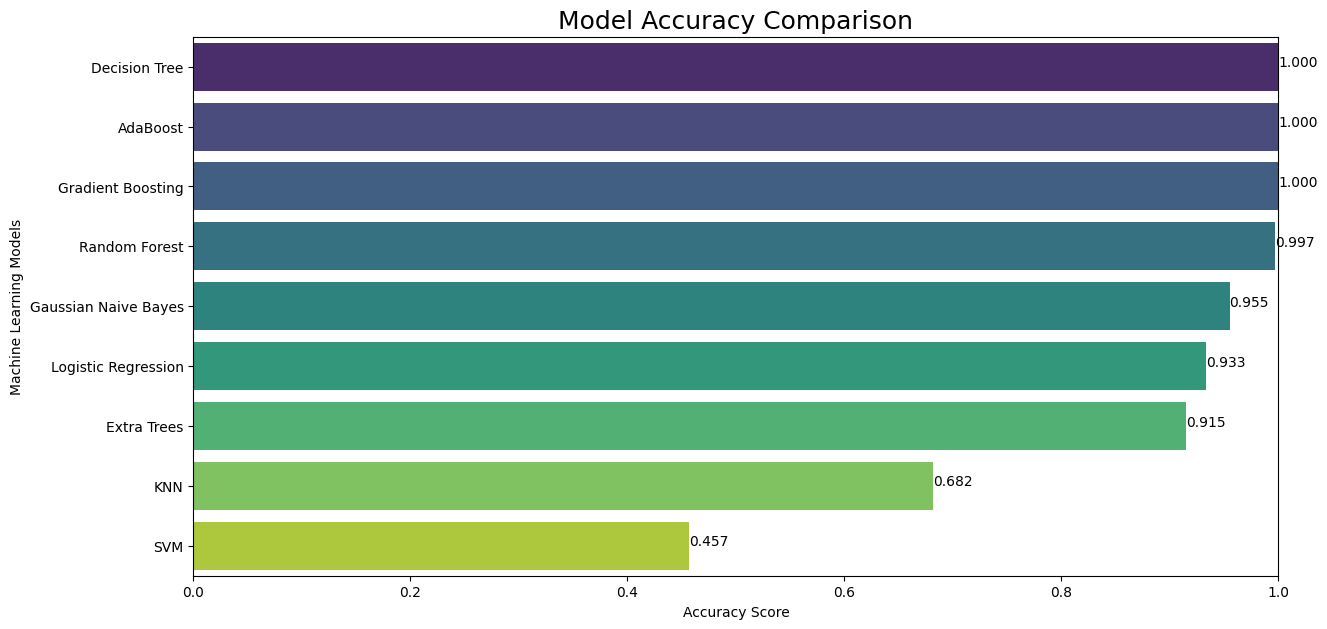



BEST MODEL
Best Model     : Decision Tree
Best Accuracy  : 1.0000


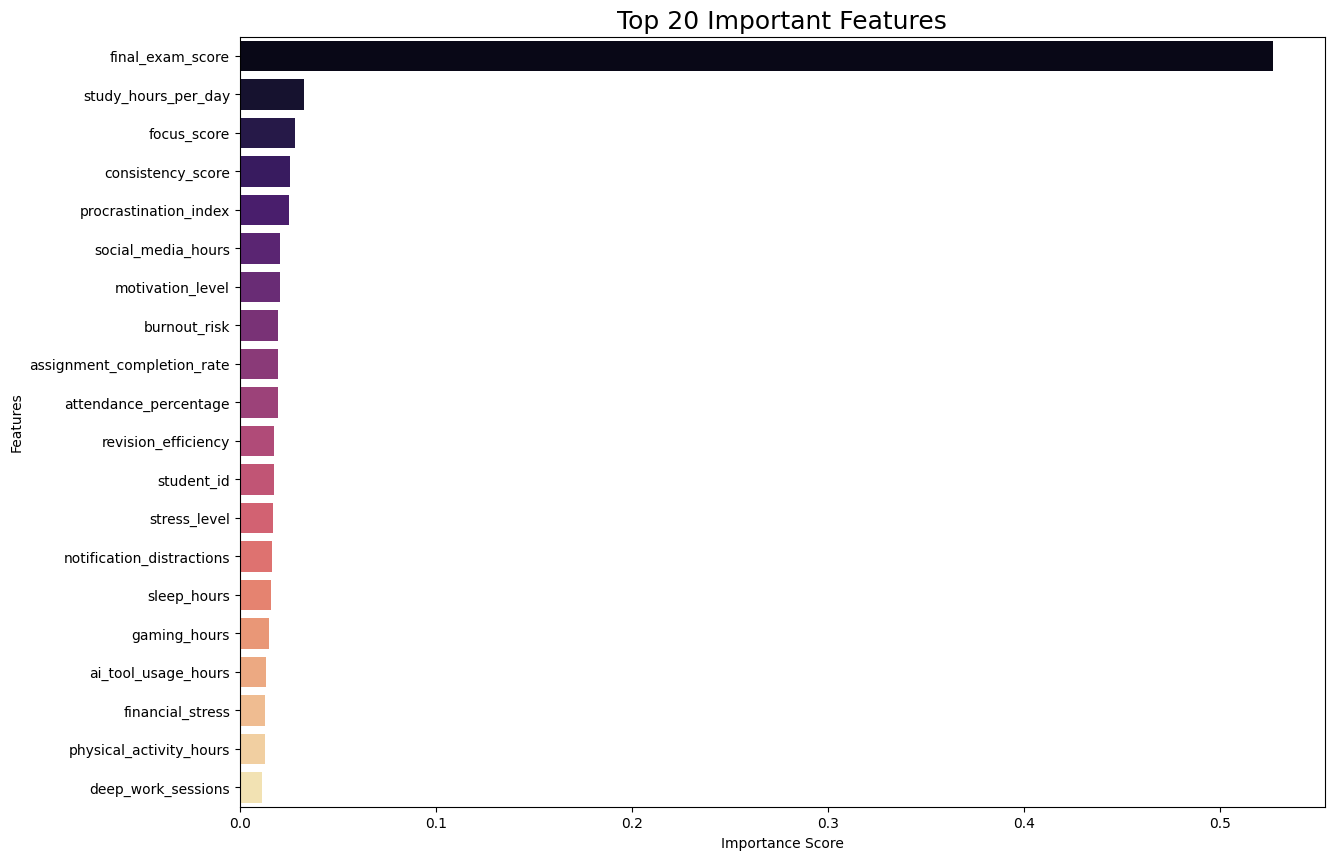



FILES SAVED SUCCESSFULLY
1. model_results.csv
2. feature_importance.csv


MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


# Target Column
target_column = "performance_category"

# Features and Target
X = df.drop(columns=[target_column])

y = df[target_column]

print("\n")
print("="*60)
print("TARGET COLUMN")
print("="*60)

print(y.value_counts())

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# IMPORTANT:
# Splitting BEFORE preprocessing to avoid DATA LEAKAGE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n")
print("="*60)
print("TRAIN TEST SHAPE")
print("="*60)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# ============================================================
# IDENTIFY CATEGORICAL & NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\n")
print("="*60)
print("CATEGORICAL COLUMNS")
print("="*60)

print(categorical_columns)

print("\n")
print("="*60)
print("NUMERICAL COLUMNS")
print("="*60)

print(numerical_columns)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=5000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "Gaussian Naive Bayes": GaussianNB()
}

# ============================================================
# TRAINING + EVALUATION
# ============================================================

results = []

plt.figure(figsize=(14, 10))

# ============================================================
# LOOP THROUGH MODELS
# ============================================================

for index, (name, model) in enumerate(models.items()):

    print("\n")
    print("="*80)
    print(f"MODEL : {name}")
    print("="*80)

    # Create Pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    pipeline.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = pipeline.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix\n")

    print(cm)

    # ========================================================
    # ROC AUC CURVE
    # ========================================================

    # Only for binary classification
    # If multiclass, ROC handled differently

    if len(y.unique()) == 2:

        # Probability Prediction
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # ROC Values
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)

        # AUC Score
        auc_score = roc_auc_score(y_test, y_prob)

        # Plot ROC Curve
        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{name} (AUC = {auc_score:.3f})"
        )

        print(f"\nROC AUC Score : {auc_score:.4f}")

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

# ============================================================
# ROC CURVE FINAL PLOT
# ============================================================

if len(y.unique()) == 2:

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

# Sort by Accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df)

# ============================================================
# ACCURACY BARPLOT
# ============================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18
)

plt.xlabel("Accuracy Score")
plt.ylabel("Machine Learning Models")

plt.xlim(0, 1)

for index, value in enumerate(results_df["Accuracy"]):

    plt.text(
        value,
        index,
        f"{value:.3f}"
    )

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model     : {best_model['Model']}")
print(f"Best Accuracy  : {best_model['Accuracy']:.4f}")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

# Only for Tree Based Models

best_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

best_tree_model.fit(X_train, y_train)

# Get Feature Names
encoded_cat_features = best_tree_model.named_steps[
    "preprocessor"
].named_transformers_[
    "cat"
].named_steps[
    "encoder"
].get_feature_names_out(categorical_columns)

all_features = numerical_columns + list(encoded_cat_features)

# Feature Importance
importances = best_tree_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14, 10))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title(
    "Top 20 Important Features",
    fontsize=18
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "model_results.csv",
    index=False
)

feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("\n")
print("="*80)
print("FILES SAVED SUCCESSFULLY")
print("="*80)

print("1. model_results.csv")
print("2. feature_importance.csv")

# ============================================================
# END OF COMPLETE MACHINE LEARNING PIPELINE
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thank you...pls upvote!!!!!!!!!!!!!!!